# Lead-Lag Networks in Metal Trading

**Projet ISF** — Détection de relations *lead/lag* entre actifs (métaux, FX, taux) via **Dynamic Time Warping (DTW)** puis construction d'un **graphe de transfert d'information** basé sur la divergence de Jensen-Shannon.

## Plan du notebook
1. **`DataLoader`** — récupération yfinance, diagnostic des manquants (test MCAR), imputation.
2. **`Preprocessing`** — log-returns, scaling, 5 filtres comparés, détection de régimes Markov.
3. **`EDA`** — corrélations multi-lags, clustermap DTW.
4. **`LeadLagDTW`** — matrice de distances DTW + matrice des décalages temporels.
5. **`ModelTuningValidation`** — Optuna + cross-validation expanding window (jamais de leak futur).
6. **`EntropyTransferGraph`** — embedding MDS + graphe d'entropie de Shannon.
7. **Conclusion** — leader / suiveur dominants.

## Conventions
- POO stricte : une classe par fichier dans `src/`, ce notebook les orchestre.
- Time-series safe : aucun `shuffle`, CV expanding window uniquement.
- Chaque choix méthodologique est justifié en markdown au-dessus de la cellule de code.

## Setup

Imports + création du dossier `outputs/` où l'on persiste figures et CSV pour la page Notion / la présentation finale.

In [ ]:
from __future__ import annotations

import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
%matplotlib inline

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
OUT = os.path.join(ROOT, "outputs")
os.makedirs(OUT, exist_ok=True)

from src.config import TICKERS
from src.data_loader import DataLoader
from src.preprocessing import Preprocessing
from src.eda import EDA
from src.lead_lag_dtw import LeadLagDTW
from src.tuning import ModelTuningValidation
from src.entropy_graph import EntropyTransferGraph

print(f"Tickers chargés : {list(TICKERS.keys())}")

Tickers chargés : ['Gold', 'Silver', 'Oil', 'EURUSD', 'JPYUSD', 'DXY', 'UST10Y', 'Bund10Y']


## Task 1 — `DataLoader`

**Objectif** : télécharger les 8 séries (Gold, Silver, Oil, EURUSD, JPYUSD, DXY, UST10Y, Bund10Y), aligner sur calendrier commun, diagnostiquer les manquants, imputer.

### Choix méthodologiques
- **Proxy Bund 10y** : `IS0L.DE` (iShares Germany Govt Bond UCITS ETF). Yahoo ne publie pas le yield Bund directement ; on utilise un ETF prix tradé en EUR avec liquidité continue.
- **Test MCAR** (Little, 1988) : on teste si les manquants sont *Missing Completely At Random* via un chi² de log-vraisemblance EM. Si $H_0$ non rejetée → forward-fill acceptable sans biais.
- **Forward-fill** : justifié pour des prix (variables *stock*) — la dernière valeur reste informative jusqu'au prochain trade. À ne **pas** appliquer aux returns (variables *flux*).

### Test de Little (formulation)
$$d^2 = \sum_{j=1}^{J} n_j (\bar{x}_j - \hat{\mu}_j)^\top \hat{\Sigma}_{jj}^{-1} (\bar{x}_j - \hat{\mu}_j) \;\sim\; \chi^2_{(\sum k_j) - k}$$
où $j$ indexe les *patterns* de manquants et $k_j$ le nombre de variables observées dans le pattern.

In [2]:
dl = DataLoader(TICKERS, start_date="2020-01-01", end_date="2025-01-01", freq="1d")
dl.fetch_data()
merged = dl.merge_data()

print(f"merged shape : {merged.shape}")
print(f"\nManquants par colonne :\n{merged.isna().sum()}")

merged shape : (1305, 8)

Manquants par colonne :
Gold       47
Silver     47
Oil        47
EURUSD      0
JPYUSD      0
DXY        47
UST10Y     47
Bund10Y    30
dtype: int64


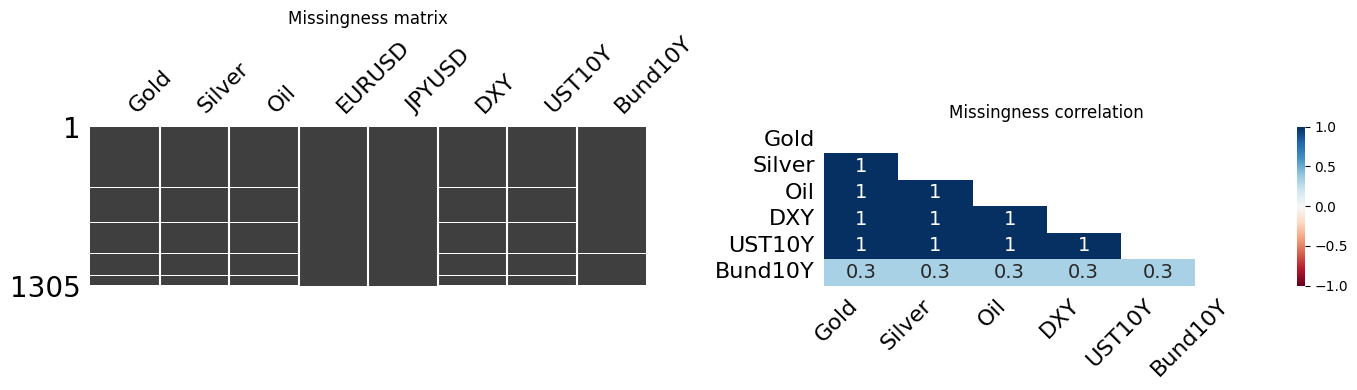

In [3]:
# Visualisation des manquants (missingno-like)
fig = dl.eda_missing(merged)
fig.savefig(os.path.join(OUT, "01_missingness.png"), dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# Test MCAR de Little
mcar = dl.missing_test(merged)
print(f"MCAR plausible (H0 non rejetée) : {mcar['mcar_plausible']}")
print(f"Détail : {mcar}")

MCAR plausible (H0 non rejetée) : True
Détail : {'per_column': {'Gold': {'F': 2.832402660632227, 'p': 0.09262858272554525}, 'Silver': {'F': 0.5978653106642419, 'p': 0.43953915899154516}, 'Oil': {'F': 2.0705369304702135, 'p': 0.15041779226472118}, 'EURUSD': {'F': 0.16027211366519492, 'p': 0.9230644544866257}, 'JPYUSD': {'F': 0.12973537703066296, 'p': 0.9424444127952358}, 'DXY': {'F': 0.014589201692512677, 'p': 0.9038800422527822}, 'UST10Y': {'F': 0.008762014587219796, 'p': 0.9254373636777108}, 'Bund10Y': {'F': 0.3756497942073189, 'p': 0.5400501141495505}}, 'mcar_plausible': True}


In [5]:
# Imputation forward-fill puis sanity check
prices = dl.impute_data(merged)
prices.to_csv(os.path.join(OUT, "01_prices.csv"))

assert prices.isna().sum().sum() == 0, "Il reste des NaN après imputation"
print(f"prices clean shape : {prices.shape}")
prices.head()

prices clean shape : (1305, 8)


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Date,,,,,,,,
2020-01-01,1524.500000,17.966000,61.180000,1.122083,0.009201,96.849998,1.882,145.580002
2020-01-02,1524.500000,17.966000,61.180000,1.122083,0.009199,96.849998,1.882,145.580002
2020-01-03,1549.199951,18.068001,63.049999,1.117144,0.009213,96.839996,1.788,146.225006
2020-01-06,1566.199951,18.097000,63.270000,1.116196,0.009262,96.669998,1.811,146.134995
2020-01-07,1571.800049,18.316000,62.700001,1.119799,0.009225,96.980003,1.827,146.119995


## Task 2 — `Preprocessing`

**Objectif** : engineering de features (log-returns, vol, MA), comparaison de 5 filtres, détection de régimes par chaîne de Markov.

### Log-returns plutôt que returns simples
$$r_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$
Avantages : additivité temporelle ($r_{t,t+k} = \sum r_{t+i}$), distribution plus proche de la normale, symétrie autour de 0.

### Comparaison des 5 filtres
| Filtre | Hypothèse | Pourquoi on le teste |
|---|---|---|
| **Kalman (local level)** | random-walk + bruit gaussien | optimal théorique, pas de fenêtre à fixer |
| **Butterworth low-pass** | bande passante plate | DSP standard, pas de ripple |
| **Savitzky–Golay** | polynôme local | préserve les pics mieux qu'une MA |
| **Moving Average** | — | baseline |
| **EMA (TA-Lib)** | pondération exponentielle, causal | standard trading, pas de leak |

### Markov Switching Regression
On modélise les rendements comme $r_t \mid S_t = s \sim \mathcal{N}(\mu_s, \sigma_s^2)$ avec $S_t$ chaîne de Markov à 2 états (calme / stressé). Référence : Hamilton (1989), implémenté dans `statsmodels.tsa.regime_switching`.

In [6]:
pp = Preprocessing(prices)
feats = pp.transform_data(ma_window=20)

print("Features générées :", list(feats.keys()))
print(f"log_returns shape : {feats['log_returns'].shape}")
feats["log_returns"].head()

Features générées : ['log_returns', 'moving_average', 'scaled']
log_returns shape : (1302, 8)


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Date,,,,,,,,
2020-01-02,0.000000,0.000000,0.000000,0.000000,-0.000294,0.000000,0.000000,0.000000
2020-01-03,0.016072,0.005661,0.030108,-0.004411,0.001565,-0.000103,-0.051237,0.004421
2020-01-06,0.010914,0.001604,0.003483,-0.000849,0.005349,-0.001757,0.012782,-0.000616
2020-01-07,0.003569,0.012029,-0.009050,0.003223,-0.004086,0.003202,0.008796,-0.000103
2020-01-08,-0.009204,-0.012526,-0.050538,-0.003870,0.003604,0.003294,0.025400,-0.001987


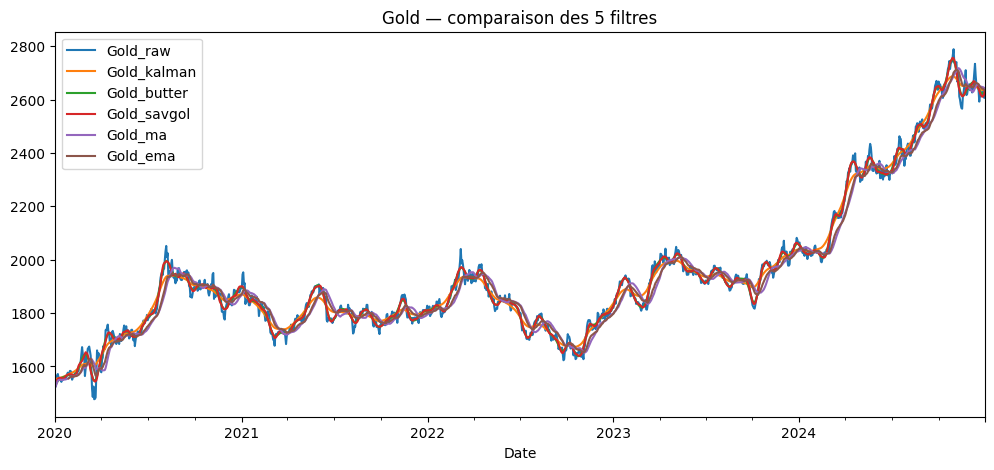

In [7]:
# Comparaison visuelle des 5 filtres sur l'actif cible
target = "Gold" if "Gold" in prices.columns else prices.columns[0]
filt = pp.apply_all_filters(target)

ax = filt.plot(figsize=(12, 5), title=f"{target} — comparaison des 5 filtres")
ax.figure.savefig(os.path.join(OUT, "02_filters.png"), dpi=120, bbox_inches="tight")
plt.show()

In [8]:
# Détection de régimes Markov à 2 états
try:
    regimes = pp.detect_regimes_markov(target)
    print(f"Distribution des régimes :\n{regimes.value_counts()}")
except Exception as e:
    print(f"[skip] Markov regimes : {e}")

Distribution des régimes :
Gold_regime
0    1032
1     272
Name: count, dtype: int64


## Task 3 — EDA

**Objectif** : explorer les corrélations à plusieurs lags et obtenir une première hiérarchie de similarité via DTW + clustering hiérarchique.

### Corrélations multi-lag
Pour $\ell \in \{0, \dots, L\}$ :
$$\rho_{X,Y}(\ell) = \mathrm{Corr}(X_t,\, Y_{t+\ell})$$
Si $\rho_{X,Y}(\ell)$ pique pour $\ell > 0$, $X$ *lead* $Y$ de $\ell$ pas (intuition à confirmer ensuite par DTW, qui n'impose pas de lag constant).

### Clustermap DTW
Matrice de distance $D_{ij}$ entre paires d'actifs, ordonnée par clustering hiérarchique (linkage = average). Permet d'identifier visuellement les blocs (ex : métaux précieux vs taux).

In [9]:
eda = EDA(prices)
corr = eda.correlation_matrix(max_lag=5)

print("Matrice de corrélation (lag = argmax) :")
corr["corr"].round(2)

Matrice de corrélation (lag = argmax) :


,Gold,Silver,Oil,EURUSD,JPYUSD,DXY,UST10Y,Bund10Y
Gold,1.00,0.78,0.14,0.06,0.01,-0.38,-0.23,0.24
Silver,0.78,1.00,0.19,0.05,0.00,-0.38,-0.09,0.14
Oil,0.14,0.19,1.00,-0.04,0.00,-0.05,0.15,-0.13
EURUSD,0.06,0.05,-0.04,1.00,0.45,-0.09,-0.07,0.08
JPYUSD,0.01,0.00,0.00,0.45,1.00,-0.05,-0.06,0.09
DXY,-0.38,-0.38,-0.05,-0.09,-0.05,1.00,0.23,-0.09
UST10Y,-0.23,-0.09,0.15,-0.07,-0.06,0.23,1.00,-0.46
Bund10Y,0.24,0.14,-0.13,0.08,0.09,-0.09,-0.46,1.00


In [ ]:
corr["corr"].to_csv(os.path.join(OUT, "03_corr.csv"))

g, D_eda = eda.dtw_clustermap()
g.fig.savefig(os.path.join(OUT, "03_dtw_clustermap.png"), dpi=120, bbox_inches="tight")
D_eda.to_csv(os.path.join(OUT, "03_dtw_distance.csv"))
plt.show()

## Task 4 — `LeadLagDTW`

**Objectif** : pour chaque paire $(X, Y)$, calculer la distance DTW *et* le décalage moyen extrait du *warping path*.

### Convention de signe
Soit $\pi = \{(i_k, j_k)\}_k$ le chemin optimal alignant $X[i_k]$ avec $Y[j_k]$ :
$$\mathrm{lag}(X, Y) = \frac{1}{|\pi|} \sum_k (j_k - i_k)$$
- $\mathrm{lag} > 0$ : $X$ **lead** $Y$ (pour matcher l'instant $i$ de $X$, DTW a dû aller chercher plus loin dans $Y$).
- $\mathrm{lag} < 0$ : $Y$ lead $X$.

Référence : MDPI 2022 *Multi-Dimensional DTW to Identify Time-Varying Lead-Lag* (sensors-22-06884).

### Bande de Sakoe-Chiba
Contrainte globale $|i_k - j_k| \le r$ (ici $r = 20$ jours). Avantages :
- évite le *pathological alignment* (un point qui s'étire sur toute la série),
- complexité $O(n \cdot r)$ au lieu de $O(n^2)$,
- borne implicitement le lag détectable à ±20 jours, ce qui est cohérent avec l'horizon macro recherché.

In [ ]:
ll = LeadLagDTW(prices, sakoe_chiba_radius=20)
res = ll.identify_lead_lag()

print("Matrice de distance DTW :")
res["distance"].round(2)

In [ ]:
print("Matrice lead-lag (ligne lead colonne si > 0) :")
res["lag"].round(2)

In [ ]:
res["distance"].to_csv(os.path.join(OUT, "04_dtw_distance.csv"))
res["lag"].to_csv(os.path.join(OUT, "04_lag_matrix.csv"))
print("Matrices sauvegardées dans outputs/.")

## Task 5 — Tuning & Validation

**Objectif** : optimiser les hyperparamètres d'un modèle prédictif `follower ~ lagged(leader)` puis valider hors-échantillon.

### Cross-validation : expanding window (jamais de shuffle)
On découpe la série en $K$ folds *chronologiques* :
$$\mathrm{train}_k = [t_0, t_k], \quad \mathrm{test}_k = [t_k + 1, t_{k+1}]$$
Aucune information future ne fuit dans l'entraînement → conforme à la règle CLAUDE.md (*time-series safe*).

### Optuna
Recherche bayésienne (TPE) sur l'espace des hyperparamètres, métrique = RMSE moyenne sur les folds. 10 trials seulement ici pour rester rapide ; à augmenter pour le livrable final.

In [ ]:
cols = list(prices.columns)
leader, follower = cols[0], cols[1]
print(f"Hypothèse testée : {leader} → {follower}")

mt = ModelTuningValidation(prices, leader=leader, follower=follower, n_splits=5)
tune = mt.tune_model(n_trials=10)

print(f"\nMeilleurs paramètres : {tune['best_params']}")
print(f"Meilleure RMSE       : {tune['best_value']:.4f}")

In [ ]:
validation = mt.validate_model()
print(f"Validation hors-échantillon : {validation}")

## Task 6 — `EntropyTransferGraph`

**Objectif** : transformer la matrice DTW en graphe de transfert d'information.

### Pipeline
1. Similarité noyau : $S_{ij} = \exp(-\lambda D_{ij})$, avec $\lambda$ choisi automatiquement (médiane des distances).
2. Distribution row-normalisée : $p_i = S_i / \sum_j S_{ij}$.
3. **Entropie de Shannon** par actif : $H(i) = -\sum_j p_{ij} \log p_{ij}$.
   - Faible $H$ = distribution piquée → l'actif a peu de "voisins" similaires → **leader candidat**.
   - Forte $H$ = distribution diffuse → suiveur réactif à plusieurs sources.
4. **Jensen-Shannon** symétrique :
$$\mathrm{JSD}(p\|q) = \tfrac{1}{2} \mathrm{KL}(p \| m) + \tfrac{1}{2} \mathrm{KL}(q \| m), \quad m = \tfrac{p+q}{2}$$
   bornée dans $[0, \log 2]$, métrique sous sa racine carrée.
5. Matrice de transfert $M_{ij} = 1 - \mathrm{JSD}(p_i, p_j)$, embedding via **MDS** (préserve les distances $\Delta = 1 - M$).

Référence : <https://en.wikipedia.org/wiki/Jensen-Shannon_divergence>.

In [ ]:
etg = EntropyTransferGraph(res["distance"])
emb = etg.compute_embeddings(method="mds")

print(f"lambda auto-calibré : {emb['lambda']:.4f}")
print("\nEntropies de Shannon (faible = leader fort) :")
emb["entropy"].sort_values().round(3)

In [ ]:
emb["transfer"].to_csv(os.path.join(OUT, "06_transfer_matrix.csv"))
emb["entropy"].to_csv(os.path.join(OUT, "06_entropy.csv"))

# Graphe : on ne garde que les arêtes au-dessus de la médiane (anti-saturation visuelle)
fig, ax = plt.subplots(figsize=(9, 7))
etg.plot_graph(threshold=float(np.median(emb["transfer"].values)), ax=ax)
fig.savefig(os.path.join(OUT, "06_entropy_graph.png"), dpi=120, bbox_inches="tight")
plt.show()

## Task 7 — Conclusion

Lecture finale du graphe : l'actif d'**entropie minimale** est le candidat *leader* (information concentrée), celui d'**entropie maximale** est le suiveur le plus diffus.

Ces conclusions sont à **croiser** avec :
- la matrice `res["lag"]` (signe et amplitude des décalages),
- la validation hors-échantillon (RMSE de la régression `follower ~ lag(leader)`),
- la lecture macro (régimes Markov détectés en Task 2).

Une cohérence entre ces trois angles renforce la crédibilité du couple lead/lag identifié.

In [ ]:
ent = emb["entropy"].sort_values()
print(f"Leader le plus fort   (entropie min) : {ent.index[0]}  (H = {ent.iloc[0]:.3f})")
print(f"Suiveur le plus diffus (entropie max) : {ent.index[-1]} (H = {ent.iloc[-1]:.3f})")
print(f"\nTous les outputs sont dans : {OUT}")